# Grounding Test
This notebook is dedicated to testing the visual grounding capabilities of the C-RADIOv4-SO400M model on egocentric assembly frames.

## Phase 0.1: Model Loading and VRAM Sanity Check
In this section, we initialize the model from local weights, perform a forward pass on a single raw frame, and reshape the output spatial features into a 2D grid.

In [17]:
import torch
import os
import tkinter as tk
from tkinter import filedialog
from PIL import Image
from transformers import AutoModel, CLIPImageProcessor
from einops import rearrange
import time

print("Loading the model (this might take a few seconds)...")

# 1. Point to the local directory where we downloaded the weights
local_repo = "../models/c_radio_weights"

# 2. Load the processor and the model into VRAM
image_processor = CLIPImageProcessor.from_pretrained(local_repo)
model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)
model.eval().cuda() # Move the model to the GPU

print("Model successfully loaded into VRAM!\n")

# 3. Choose the frame using a File Explorer dialog
# Initialize tkinter and hide the main window
root = tk.Tk()
root.attributes('-topmost', True) # Bring the dialog to the front
root.withdraw()

# Open the file explorer starting from the default directory
image_path = filedialog.askopenfilename(
    initialdir=os.path.abspath("../data/extracted_frames/"),
    title="Select a frame for testing",
    filetypes=(("JPEG files", "*.jpg"), ("All files", "*.*"))
)

root.destroy() # Close the tkinter instance

# Safety check if the user clicks "Cancel"
if not image_path:
    raise ValueError("No file was selected. Please run the cell again.")

print(f"\nLoading image from: {image_path}")
image = Image.open(image_path).convert('RGB')

# 4. Image preprocessing
pixel_values = image_processor(images=image, return_tensors='pt', do_resize=True).pixel_values
pixel_values = pixel_values.cuda()

print(f"Input image tensor shape: {pixel_values.shape}")

# 5. Inference (Memory critical phase)
print("Starting inference...")
start_time = time.time()

# Using torch.no_grad() is vital to prevent allocating memory for training
with torch.no_grad():
    # C-RADIOv4 returns two tensors: a global summary and dense spatial features
    summary, spatial_features = model(pixel_values)

# 6. Reshape the spatial features
# The patch size of C-RADIO is 16. We use einops to convert the 1D tensor back to a 2D grid (B, D, H, W)
patch_size = 16
h = pixel_values.shape[-2] // patch_size
w = pixel_values.shape[-1] // patch_size
spatial_features_2d = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)

end_time = time.time()

# 7. Results
print("\n--- TEST SUCCESSFULLY COMPLETED ---")
print(f"Local inference time: {end_time - start_time:.4f} seconds")
print(f"Summary Token shape (Global concept): {summary.shape}")
print(f"Spatial Features shape (Dense 2D grid): {spatial_features_2d.shape}")

Loading the model (this might take a few seconds)...


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

Model successfully loaded into VRAM!


Loading image from: C:/Users/ADV/Universita/Magistrale/Tesi/vad-project/data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg
Input image tensor shape: torch.Size([1, 3, 512, 512])
Starting inference...

--- TEST SUCCESSFULLY COMPLETED ---
Local inference time: 0.0195 seconds
Summary Token shape (Global concept): torch.Size([1, 2304])
Spatial Features shape (Dense 2D grid): torch.Size([1, 1152, 32, 32])


## Phase 0.1.5: Unsupervised Semantic Feature Visualization (PCA)

This section reduces the dense 1152-dimensional spatial features using PCA and plots them as an RGB semantic map alongside the original image. 

Running PCA to visualize semantic features...


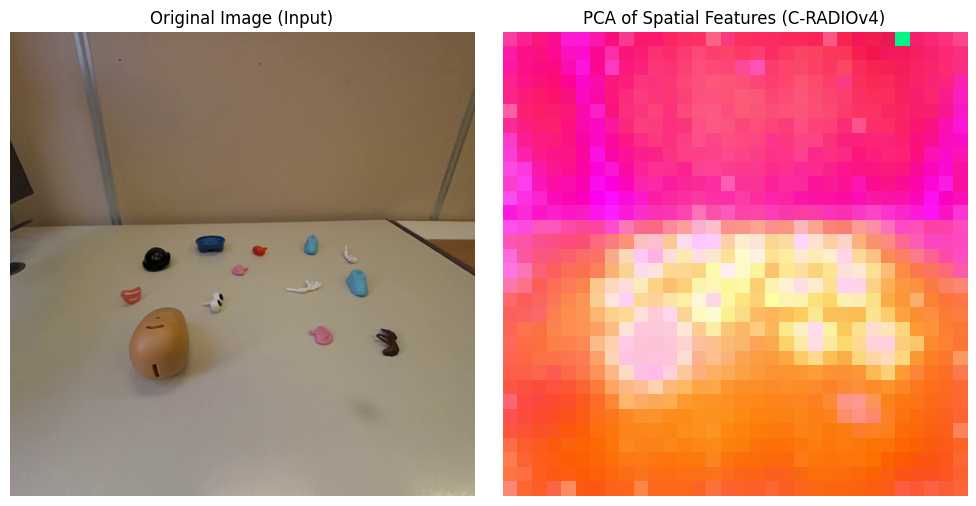

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("Running PCA to visualize semantic features...")

# 1. Remove the batch dimension from the 2D features [1, 1152, 32, 32] -> [1152, 32, 32]
features_np = spatial_features_2d[0].cpu().numpy()

# 2. Flatten spatial dimensions for PCA -> [1024, 1152] (1024 pixels, 1152 features)
features_flat = features_np.reshape(features_np.shape[0], -1).T 

# 3. Reduce from 1152 dimensions down to 3 dimensions (RGB)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(features_flat)

# 4. Normalize values between 0 and 1 to plot them as RGB colors
pca_features_norm = (pca_features - pca_features.min(0)) / (pca_features.max(0) - pca_features.min(0))

# 5. Reshape back to the 32x32 grid -> [32, 32, 3]
pca_img = pca_features_norm.reshape(32, 32, 3)

# 6. Plot the results!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image (resized for comparison)
axes[0].imshow(image.resize((512, 512)))
axes[0].set_title("Original Image (Input)")
axes[0].axis('off')

# PCA map of the features
axes[1].imshow(pca_img)
axes[1].set_title("PCA of Spatial Features (C-RADIOv4)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Phase 0.2: Language-Guided Semantic Grounding

In this section, we load the `visual_dictionary.json` containing the physical descriptions of the assembly parts. We encode these text prompts using the model's text encoder and compute the cosine similarity against the 2D spatial feature grid extracted in Phase 0.1. Finally, we upsample the resulting heatmaps, apply a threshold to isolate the highest activations, and extract bounding boxes for each component to verify the model's grounding accuracy.

Starting Phase 0.2: Language-Guided Grounding (Absolute Cosine Similarity)...
Loaded 11 components.


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Extracting text embeddings and computing similarities...


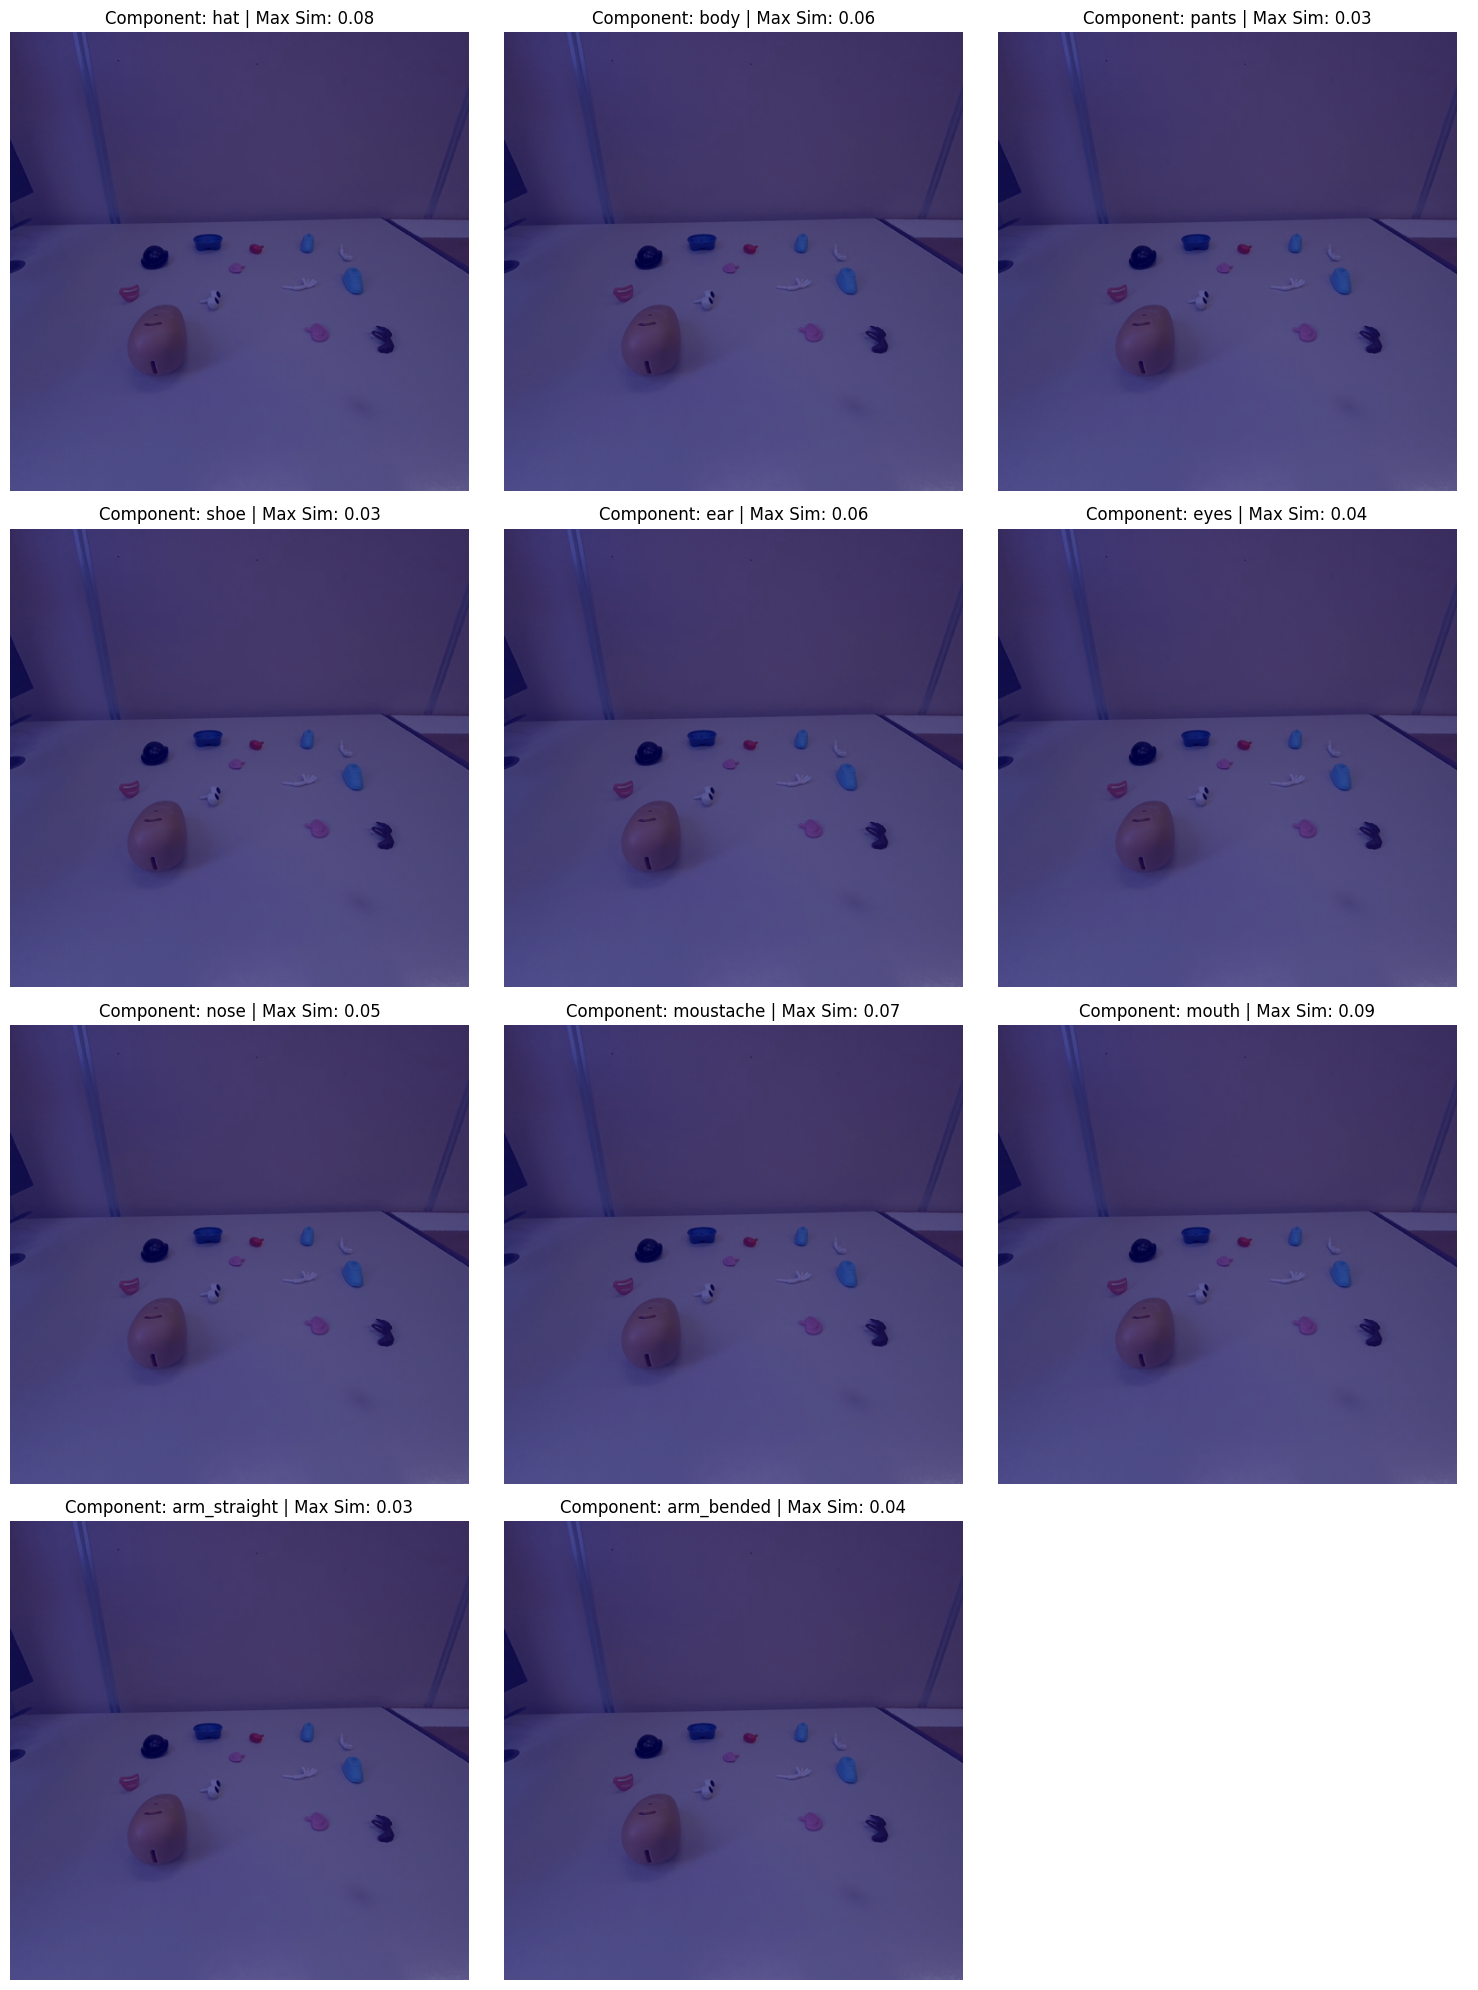

Grounding Visualization Complete!


In [2]:
import json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from transformers import AutoTokenizer, AutoModel

print("Starting Phase 0.2: Language-Guided Grounding (Absolute Cosine Similarity)...")

# 1. Load the Visual Dictionary
dict_path = '../configs/visual_dictionary.json'
with open(dict_path, 'r') as f:
    visual_dict = json.load(f)

prompt_template = "a photo of a {}"
part_names = list(visual_dict.keys())
prompts = [prompt_template.format(desc) for desc in visual_dict.values()]

print(f"Loaded {len(part_names)} components.")

# 2. Load Tokenizer and Text Model (SigLIP)
siglip_repo = "google/siglip-so400m-patch14-384"
tokenizer = AutoTokenizer.from_pretrained(siglip_repo)
siglip_model = AutoModel.from_pretrained(siglip_repo).eval().to('cuda')
inputs = tokenizer(prompts, padding=True, return_tensors="pt").to('cuda')

# 3. Extract Text Embeddings and Normalize Features
print("Extracting text embeddings and computing similarities...")
with torch.no_grad():
    text_outputs = siglip_model.get_text_features(**inputs)
    
    # Safely extract the raw tensor
    if hasattr(text_outputs, 'pooler_output'):
        text_features = text_outputs.pooler_output
    elif hasattr(text_outputs, 'text_embeds'):
        text_features = text_outputs.text_embeds
    else:
        text_features = text_outputs
        
    text_norm = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    spatial_norm = spatial_features_2d / spatial_features_2d.norm(p=2, dim=1, keepdim=True)

# 4. Compute RAW Cosine Similarity [-1 to 1] (No Softmax!)
similarity_maps = torch.einsum('bdhw,nd->nhw', spatial_norm, text_norm)

# 5. Upsample the Similarity Maps
similarity_maps = similarity_maps.unsqueeze(1)
heatmaps_up = F.interpolate(similarity_maps, size=(512, 512), mode='bicubic', align_corners=False)
heatmaps_up = heatmaps_up.squeeze(1).cpu().numpy()

# 6. Visualization and Smart Thresholding
cols = 3
rows = (len(part_names) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, name in enumerate(part_names):
    ax = axes[i]
    heatmap = heatmaps_up[i]
    max_sim = heatmap.max()
    
    ax.imshow(image.resize((512, 512)))
    
    # Fixed absolute boundaries prevent the "mirage" effect of min-max scaling
    im = ax.imshow(heatmap, cmap='jet', alpha=0.5, vmin=0.15, vmax=0.30)
    
    # Draw Bounding Box ONLY if the model is confident the object exists (sim > 0.22)
    if max_sim > 0.22:
        # Find the core of the activation
        threshold = np.percentile(heatmap[heatmap > 0.20], 95) if (heatmap > 0.20).any() else max_sim * 0.95
        y_indices, x_indices = np.where(heatmap >= threshold)
        
        if len(x_indices) > 0 and len(y_indices) > 0:
            x_min, x_max = x_indices.min(), x_indices.max()
            y_min, y_max = y_indices.min(), y_indices.max()
            
            rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            
    ax.set_title(f"Component: {name} | Max Sim: {max_sim:.2f}")
    ax.axis('off')

for j in range(len(part_names), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
print("Grounding Visualization Complete!")

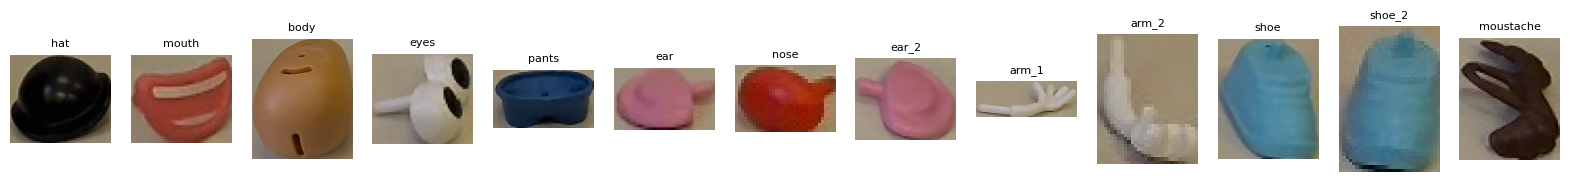

In [18]:
import json
import cv2
import matplotlib.pyplot as plt

def extract_visual_exemplars(image_path, json_path):
    # Load the original frame
    image = cv2.imread(image_path)
    
    # Safety check: if OpenCV can't find the image, stop immediately
    if image is None:
        raise FileNotFoundError(f"Immagine non trovata al percorso: {image_path}")
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Parse the Labelme JSON file
    with open(json_path, 'r') as file:
        annotation_data = json.load(file)
        
    visual_dictionary = {}
    
    # Extract each bounding box and crop the image
    for shape in annotation_data['shapes']:
        label = shape['label']
        points = shape['points']
        
        # Extract min and max coordinates
        x_min, y_min = int(points[0][0]), int(points[0][1])
        x_max, y_max = int(points[1][0]), int(points[1][1])
        
        # Mathematical crop of the tensor
        crop = image[y_min:y_max, x_min:x_max]
        
        # Handle duplicates (e.g., two ears or two shoes)
        if label in visual_dictionary:
            label = f"{label}_2"
            
        visual_dictionary[label] = crop
        
    return visual_dictionary

# Define the updated relative paths
image_file = "../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg"
json_file = "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json"

# Execute the extraction using the correct paths
exemplars = extract_visual_exemplars(image_file, json_file)

# Visualize the extracted crops to ensure mathematical accuracy
fig, axes = plt.subplots(1, len(exemplars), figsize=(20, 5))
for ax, (label, crop) in zip(axes, exemplars.items()):
    ax.imshow(crop)
    ax.set_title(label, fontsize=8)
    ax.axis('off')
plt.show()

In [19]:
import torch
import torch.nn.functional as F
from PIL import Image

print("--- CREATING THE VECTOR DATABASE FOR MR. POTATO COMPONENTS (FIXED RESOLUTION) ---")
visual_signatures_db = {}

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    for label, crop_np in exemplars.items():
        # 1. Convert the numpy array crop back to a PIL Image
        crop_pil = Image.fromarray(crop_np)
        
        # 2. Force resize the crop to a supported resolution multiple of 16 (e.g., 224x224)
        # This completely avoids the RADIO resolution step error for small crops
        crop_pil_resized = crop_pil.resize((224, 224), Image.Resampling.BICUBIC)
        
        # 3. Apply the preprocessing pipeline
        crop_pixel_values = image_processor(images=crop_pil_resized, return_tensors='pt', do_resize=True).pixel_values
        crop_pixel_values = crop_pixel_values.cuda()
        
        # 4. Forward pass through the C-RADIOv4 backbone
        crop_summary, _ = model(crop_pixel_values)
        
        # 5. L2 Normalize the vector for Cosine Similarity
        normalized_vector = F.normalize(crop_summary, p=2, dim=-1)
        
        # 6. Store on CPU memory
        visual_signatures_db[label] = normalized_vector.cpu()

print(f"\nSuccess! Successfully extracted and normalized {len(visual_signatures_db)} geometric signatures.")
print("Registered component labels in the database:", list(visual_signatures_db.keys()))

--- CREATING THE VECTOR DATABASE FOR MR. POTATO COMPONENTS (FIXED RESOLUTION) ---

Success! Successfully extracted and normalized 13 geometric signatures.
Registered component labels in the database: ['hat', 'mouth', 'body', 'eyes', 'pants', 'ear', 'nose', 'ear_2', 'arm_1', 'arm_2', 'shoe', 'shoe_2', 'moustache']


--- TESTING ALTERNATIVE COMPONENT EXECUTIONS ---


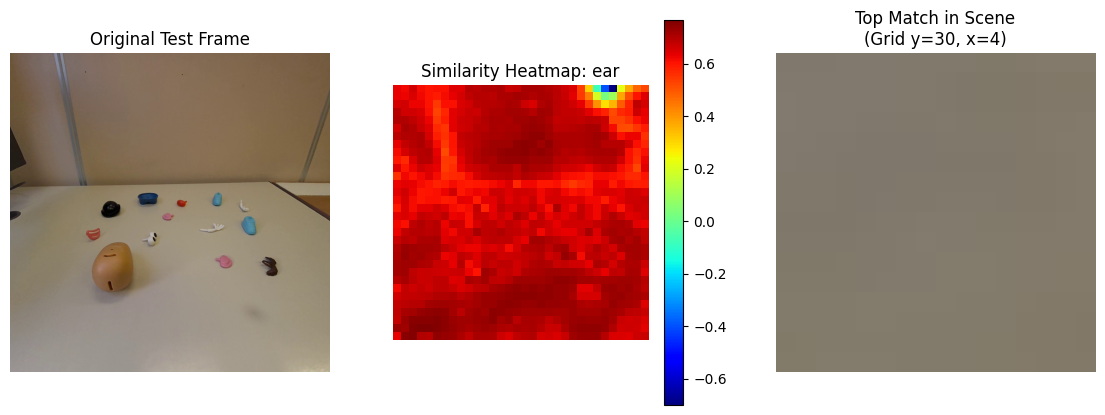

Test completed for 'ear'! Check where it matched.


In [39]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from einops import rearrange

print("--- TESTING ALTERNATIVE COMPONENT EXECUTIONS ---")
model.eval()
patch_size = 16

# Choose the component you want to test: "mouth", "eyes", "moustache", "ears", etc.
target_label = "ear" 

if target_label not in exemplars:
    raise ValueError(f"Label '{target_label}' not found in exemplars! Available: {list(exemplars.keys())}")

with torch.no_grad():
    crop_np = exemplars[target_label]
    crop_pil = Image.fromarray(crop_np).resize((224, 224), Image.Resampling.BICUBIC)
    
    crop_pixel_values = image_processor(images=crop_pil, return_tensors='pt', do_resize=True).pixel_values.cuda()
    _, crop_spatial = model(crop_pixel_values)
    
    h_c = crop_pixel_values.shape[-2] // patch_size
    w_c = crop_pixel_values.shape[-1] // patch_size
    crop_grid = rearrange(crop_spatial, 'b (h w) d -> b d h w', h=h_c, w=w_c)
    
    # Global average signature of the chosen component
    component_vector = F.adaptive_avg_pool2d(crop_grid, (1, 1)).squeeze(-1).squeeze(-1)
    component_vector = F.normalize(component_vector, p=2, dim=-1) # Shape [1, Dim]

# Extract scene spatial grid
test_image_path = image_path
test_image = Image.open(test_image_path).convert('RGB')
test_pixel_values = image_processor(images=test_image, return_tensors='pt', do_resize=True).pixel_values.cuda()

with torch.no_grad():
    _, spatial_features = model(test_pixel_values)
    
    h = test_pixel_values.shape[-2] // patch_size
    w = test_pixel_values.shape[-1] // patch_size
    scene_grid = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)
    scene_grid_normalized = F.normalize(scene_grid, p=2, dim=1)

# Compute similarity map for the new label
query_vector = component_vector.unsqueeze(-1).unsqueeze(-1)
similarity_map = torch.sum(scene_grid_normalized * query_vector, dim=1)
sim_map_np = similarity_map.squeeze().cpu().numpy()

# Find top match location and patch
max_idx = np.unravel_index(np.argmax(sim_map_np), sim_map_np.shape)
best_patch_y, best_patch_x = max_idx
pixel_y = int(best_patch_y * patch_size)
pixel_x = int(best_patch_x * patch_size)
matched_patch_region = test_image.crop((pixel_x, pixel_y, pixel_x + patch_size, pixel_y + patch_size))

# Plot results
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_image)
plt.title(f"Original Test Frame")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sim_map_np, cmap='jet')
plt.colorbar()
plt.title(f"Similarity Heatmap: {target_label}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched_patch_region)
plt.title(f"Top Match in Scene\n(Grid y={best_patch_y}, x={best_patch_x})")
plt.axis('off')

plt.show()
print(f"Test completed for '{target_label}'! Check where it matched.")

--- DIAGNOSTIC: FINDING WHAT THE MODEL MATCHES TO THE 'NOSE' ---
Highest similarity found at patch grid coordinates (y=23, x=11)


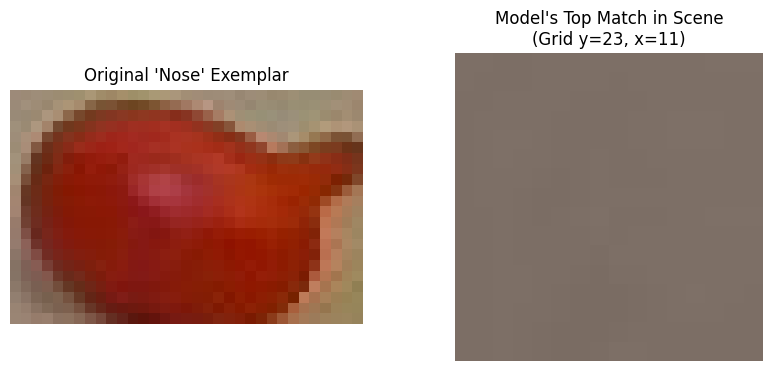

In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from einops import rearrange

print("--- DIAGNOSTIC: FINDING WHAT THE MODEL MATCHES TO THE 'NOSE' ---")
model.eval()
patch_size = 16

# 1. Extract the "nose" signature using the exact same pipeline we used before
with torch.no_grad():
    nose_crop = exemplars["nose"]
    nose_pil = Image.fromarray(nose_crop).resize((224, 224), Image.Resampling.BICUBIC)
    
    crop_pixel_values = image_processor(images=nose_pil, return_tensors='pt', do_resize=True).pixel_values.cuda()
    _, crop_spatial = model(crop_pixel_values)
    
    h_c = crop_pixel_values.shape[-2] // patch_size
    w_c = crop_pixel_values.shape[-1] // patch_size
    crop_grid = rearrange(crop_spatial, 'b (h w) d -> b d h w', h=h_c, w=w_c)
    
    # Global average vector of the nose crop
    nose_vector = F.adaptive_avg_pool2d(crop_grid, (1, 1)).squeeze(-1).squeeze(-1)
    nose_vector = F.normalize(nose_vector, p=2, dim=-1) # Shape [1, Dim]

# 2. Extract spatial grid of the test scene
test_image_path = image_path
test_image = Image.open(test_image_path).convert('RGB')
test_pixel_values = image_processor(images=test_image, return_tensors='pt', do_resize=True).pixel_values.cuda()

with torch.no_grad():
    _, spatial_features = model(test_pixel_values)
    
    h = test_pixel_values.shape[-2] // patch_size
    w = test_pixel_values.shape[-1] // patch_size
    scene_grid = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)
    scene_grid_normalized = F.normalize(scene_grid, p=2, dim=1) # [1, Dim, H, W]

# 3. Compute similarity map
query_vector = nose_vector.unsqueeze(-1).unsqueeze(-1) # [1, Dim, 1, 1]
similarity_map = torch.sum(scene_grid_normalized * query_vector, dim=1) # [1, H, W]
sim_map_np = similarity_map.squeeze().cpu().numpy()

# 4. Find the exact coordinates (patch index) of the maximum activation
max_idx = np.unravel_index(np.argmax(sim_map_np), sim_map_np.shape)
best_patch_y, best_patch_x = max_idx
print(f"Highest similarity found at patch grid coordinates (y={best_patch_y}, x={best_patch_x})")

# Map patch coordinates back to original image pixel coordinates
orig_w, orig_h = test_image.size
scale_y = orig_h / h
scale_x = orig_w / w

pixel_y = int(best_patch_y * patch_size)
pixel_x = int(best_patch_x * patch_size)

# Crop the region in the test image corresponding to this patch
matched_patch_region = test_image.crop((pixel_x, pixel_y, pixel_x + patch_size, pixel_y + patch_size))

# 5. Plot the comparison: Original Nose Crop vs What the model matched in the scene
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(nose_crop)
plt.title("Original 'Nose' Exemplar")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(matched_patch_region)
plt.title(f"Model's Top Match in Scene\n(Grid y={best_patch_y}, x={best_patch_x})")
plt.axis('off')

plt.show()

--- INSPECTING WHAT C-RADIOV4 SEES AS 'NOSE' ---
Peak found at patch grid coordinates: y=30, x=4


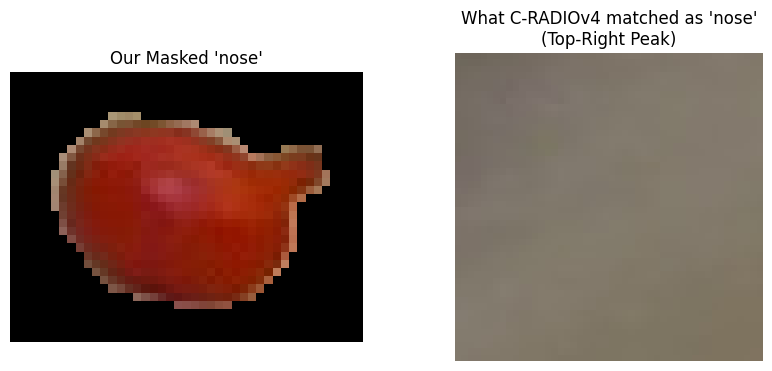

In [ ]:
import json
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from einops import rearrange

print("--- 1. LOADING EXEMPLARS WITH EXACT POLYGON MASKS (OPENCV) ---")

def extract_polygon_exemplars(image_path, json_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    with open(json_path, 'r') as file:
        data = json.load(file)
        
    masked_exemplars = {}
    
    for shape in data['shapes']:
        label = shape['label']
        points = shape['points']
        
        # Handle duplicate labels (e.g. multiple ears or shoes)
        if label in masked_exemplars:
            label = f"{label}_2"
            
        pts = np.array(points, dtype=np.int32)
        x_min, y_min = np.min(pts[:, 0]), np.min(pts[:, 1])
        x_max, y_max = np.max(pts[:, 0]), np.max(pts[:, 1])
        
        # Safety margin
        margin = 5
        h_img, w_img, _ = image.shape
        x_min_m = max(0, x_min - margin)
        y_min_m = max(0, y_min - margin)
        x_max_m = min(w_img, x_max + margin)
        y_max_m = min(h_img, y_max + margin)
        
        crop = image[y_min_m:y_max_m, x_min_m:x_max_m].copy()
        
        # Create mask using OpenCV fillPoly (shifting points relative to the crop)
        mask = np.zeros((crop.shape[0], crop.shape[1]), dtype=np.uint8)
        shifted_pts = pts - np.array([x_min_m, y_min_m])
        cv2.fillPoly(mask, [shifted_pts], 255)
        
        # Convert mask to float 0.0 - 1.0 and expand dimensions for RGB channels
        mask_float = mask.astype(np.float32) / 255.0
        mask_3ch = np.expand_dims(mask_float, axis=-1)
        
        # Zero out (blacken) everything outside the polygon mask
        masked_crop = crop * mask_3ch
        
        masked_exemplars[label] = masked_crop.astype(np.uint8)
        
    return json.loads(json.dumps(data)), masked_exemplars # metadata and crops

# Load using your json path variable
json_path_str = "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json"
_, polygon_exemplars = extract_polygon_exemplars(image_file, json_path_str)

print(f"Successfully extracted {len(polygon_exemplars)} polygon-masked exemplars: {list(polygon_exemplars.keys())}")

# Quick visualization of the masked crops (background should be pure black)
fig, axes = plt.subplots(1, len(polygon_exemplars), figsize=(20, 4))
for ax, (label, crop) in zip(axes, polygon_exemplars.items()):
    ax.imshow(crop)
    ax.set_title(label, fontsize=8)
    ax.axis('off')
plt.show()

print("\n--- 2. RUNNING GROUNDING TEST WITH MASKED EXEMPLAR ---")
model.eval()
patch_size = 16

target_label = "mouth"
if target_label in polygon_exemplars:
    crop_np = polygon_exemplars[target_label]
    crop_pil = Image.fromarray(crop_np).resize((224, 224), Image.Resampling.BICUBIC)
    
    crop_pixel_values = image_processor(images=crop_pil, return_tensors='pt', do_resize=True).pixel_values.cuda()
    
    with torch.no_grad():
        _, crop_spatial = model(crop_pixel_values)
        h_c = crop_pixel_values.shape[-2] // patch_size
        w_c = crop_pixel_values.shape[-1] // patch_size
        crop_grid = rearrange(crop_spatial, 'b (h w) d -> b d h w', h=h_c, w=w_c)
        
        component_vector = F.adaptive_avg_pool2d(crop_grid, (1, 1)).squeeze(-1).squeeze(-1)
        component_vector = F.normalize(component_vector, p=2, dim=-1)

    test_image = Image.open(image_file).convert('RGB')
    test_pixel_values = image_processor(images=test_image, return_tensors='pt', do_resize=True).pixel_values.cuda()
    
    with torch.no_grad():
        _, spatial_features = model(test_pixel_values)
        h = test_pixel_values.shape[-2] // patch_size
        w = test_pixel_values.shape[-1] // patch_size
        scene_grid = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)
        scene_grid_normalized = F.normalize(scene_grid, p=2, dim=1)

    query_vector = component_vector.unsqueeze(-1).unsqueeze(-1)
    similarity_map = torch.sum(scene_grid_normalized * query_vector, dim=1)
    sim_map_np = similarity_map.squeeze().cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_image)
    plt.title("Original Test Frame")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(sim_map_np, cmap='jet')
    plt.colorbar()
    plt.title(f"Masked Similarity Heatmap: {target_label}")
    plt.axis('off')
    plt.show()
    print(f"Grounding test executed cleanly with OpenCV polygon mask for '{target_label}'!")
else:
    print(f"Label '{target_label}' not found.")